# Data Wrangling

Load & transform NBA dataset

Ensure the two datasets are located in folder called data (or update load filepath)

### Import & Load Data

In [1]:
# Install polars if not already installed


# Imports
import pandas as pd
import polars as pl
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder


In [2]:
# Load raw csv data
df_shots = pl.read_csv("shotdetail_2024.csv", try_parse_dates=True)
df_cdnnba = pl.read_csv("cdnnba_2024.csv", try_parse_dates=True)

# Merge cdnnba & shots dataframes
df_merged = df_shots.join(df_cdnnba, how='left', left_on=['GAME_ID', 'GAME_EVENT_ID'], right_on=['gameId', 'actionNumber'])
df_merged = df_merged.with_columns(pl.concat_str([pl.col('GAME_ID'), pl.col('GAME_EVENT_ID')], separator="_").alias('Record_Id'))


### Exploration

In [3]:
df_merged.dtypes

[String,
 Int64,
 Int64,
 Int64,
 String,
 Int64,
 String,
 Int64,
 Int64,
 Int64,
 String,
 String,
 String,
 String,
 String,
 String,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 String,
 String,
 String,
 Datetime(time_unit='us', time_zone='UTC'),
 Int64,
 String,
 String,
 String,
 String,
 Int64,
 Float64,
 Float64,
 Int64,
 Int64,
 Int64,
 Datetime(time_unit='us', time_zone='UTC'),
 Int64,
 Boolean,
 Int64,
 Int64,
 Int64,
 String,
 String,
 String,
 Int64,
 String,
 String,
 String,
 Int64,
 String,
 String,
 String,
 Int64,
 String,
 Int64,
 String,
 String,
 Float64,
 String,
 String,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 Int64,
 String,
 Int64,
 Int64,
 String,
 Int64,
 Int64,
 Int64,
 Int64,
 String,
 Int64,
 String]

In [4]:
df_merged.describe()

statistic,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,y,possession,scoreHome,…,side,description,personIdsFilter,teamId,teamTricode,descriptor,jumpBallRecoveredName,jumpBallRecoverdPersonId,playerName,playerNameI,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,area,areaDetail,shotDistance,shotResult,blockPlayerName,blockPersonId,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,officialId,turnoverTotal,stealPlayerName,stealPersonId,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,Record_Id
str,str,f64,f64,f64,str,f64,str,f64,f64,f64,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str,str,f64,str,str,str,str,f64,f64,f64,f64,f64,…,str,str,str,f64,str,str,str,f64,str,str,str,f64,str,f64,str,str,f64,str,str,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,str,f64,f64,f64,f64,str,f64,str
"""count""","""219527""",219527.0,219527.0,219527.0,"""219527""",219527.0,"""219527""",219527.0,219527.0,219527.0,"""219527""","""219527""","""219527""","""219527""","""219527""","""219527""",219527.0,219527.0,219527.0,219527.0,219527.0,219527.0,"""219527""","""219527""","""219524""","""219524""",219524.0,"""219524""","""219524""","""219524""","""219524""",219524.0,219524.0,219524.0,219524.0,219524.0,…,"""219524""","""219524""","""219524""",219524.0,"""219524""","""150690""","""0""",0.0,"""219524""","""219524""","""0""",0.0,"""0""",0.0,"""219523""","""219524""",219524.0,"""219524""","""11993""",11993.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,102566.0,"""65312""",65312.0,65312.0,0.0,0.0,"""0""",0.0,"""219527"""
"""null_count""","""0""",0.0,0.0,0.0,"""0""",0.0,"""0""",0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""3""","""3""",3.0,"""3""","""3""","""3""","""3""",3.0,3.0,3.0,3.0,3.0,…,"""3""","""3""","""3""",3.0,"""3""","""68837""","""219527""",219527.0,"""3""","""3""","""219527""",219527.0,"""219527""",219527.0,"""4""","""3""",3.0,"""3""","""207534""",207534.0,219527.0,219527.0,219527.0,219527.0,219527.0,219527.0,"""219527""",219527.0,116961.0,"""154215""",154215.0,154215.0,219527.0,219527.0,"""219527""",219527.0,"""0"""
"""mean""",null,2.2401e7,330.567493,1.3752e6,null,1.6106e9,null,2.480843,5.385274,28.853617,null,null,null,null,null,null,14.003635,-2.252251,97.446464,1.0,0.467214,2.0247e7,null,null,null,"""2025-01-19 00:54:21.708397+00:…",2.480836,null,null,null,null,1.3752e6,49.833238,49.493792,1.6106e9,56.89305,…,null,null,null,1.6106e9,null,null,null,null,null,null,null,null,null,null,null,null,14.484858,null,null,1.3805e6,null,null,null,null,null,null,null,null,9.854425,null,1.3309e6,3.121279,null,null,null,null,null
"""std""",null,354.580103,199.058742,550394.782499,null,8.705154,null,1.127515,3.450603,17.407554,null,null,null,null,null,null,10.698021,116.722689,96.627021,0.0,0.498925,4443.34033,null,null,null,null,1.127517,null,null,null,null,550386.873113,35.563115,23.342663,8.70513,34.286788,…,null,null,null,8.70513,null,null,null,null,null,null,null,null,null,null,null,null,10.714503,null,null,545722.906185,null,null,null,null,null,null,null,null,7.306994,null,585964.051679,2.412323,null,null,null,null,null
"""min""","""Shot Chart Detail""",2.2400001e7,4.0,2544.0,"""A.J. Lawson""",1.6106e9,"""Atlanta Hawks""",1.0,0.0,0.0,"""Made Shot""","""Alley Oop Dunk Shot""","""2PT Field Goal""","""Above the Break 3""","""Back Court(BC)""","""16-24 ft.""",0.0,-250.0,-52.0,1.0,0.0,2.0241022e7,"""ATL""","""ATL""","""PT00M00.00S""","""2024-10-22 23:36:07.500000+00:…",1.0,"""OVERTIME""","""2pt""","""DUNK""","""""",2544.0,0.0,0.0,1.6106e9,0.0,…,"""left""","""

## Data Cleaning

In [5]:
# Convert data types
df_merged = df_merged.with_columns(
    pl.col('GAME_DATE').cast(pl.String).str.to_datetime(format="%Y%m%d").alias('game_date'),
    pl.when(pl.col('HTM') == pl.col('teamTricode')).then(1).otherwise(0).alias('isHomeTeam'),
    pl.duration(minutes=pl.col('MINUTES_REMAINING'), seconds=pl.col('SECONDS_REMAINING')).alias('time_remaining'),
    (pl.col('scoreHome') - pl.col('scoreAway')).alias('score_margin_after'),
    pl.when(pl.col('SHOT_MADE_FLAG') == 1).then(
        pl.when(pl.col('actionType') == "3pt").then(pl.lit(3)).otherwise(pl.lit(2))
        ).otherwise(pl.lit(0)).alias('score_change'), 
    pl.when(pl.col('shotDistance').is_null()).then(pl.col('SHOT_DISTANCE')).otherwise(pl.col('shotDistance')).alias('shotDistance')
)

# Convert score to be relative to player taking actions perspective
df_merged = df_merged.with_columns(
    pl.when(pl.col('teamTricode') == pl.col('HTM'))
        .then(pl.col('score_margin_after') - pl.col('score_change'))
    .otherwise(pl.col('score_margin_after')*-1 - pl.col('score_change')).alias('relative_margin_before')
)

In [6]:
df_merged.head(5)

GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,y,possession,scoreHome,scoreAway,…,jumpBallRecoveredName,jumpBallRecoverdPersonId,playerName,playerNameI,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,area,areaDetail,shotDistance,shotResult,blockPlayerName,blockPersonId,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,officialId,turnoverTotal,stealPlayerName,stealPersonId,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,Record_Id,game_date,isHomeTeam,time_remaining,score_margin_after,score_change,relative_margin_before
str,i64,i64,i64,str,i64,str,i64,i64,i64,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,"datetime[μs, UTC]",i64,str,str,str,str,i64,f64,f64,i64,i64,i64,…,str,i64,str,str,str,i64,str,i64,str,str,f64,str,str,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,str,i64,i64,i64,i64,str,i64,str,datetime[μs],i32,duration[μs],i64,i32,i64
"""Shot Chart Detail""",22400001,7,1642258,"""Zaccharie Risacher""",1610612737,"""Atlanta Hawks""",1,11,43,"""Missed Shot""","""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Left Side Center(LC)""","""24+ ft.""",26,-168,205,1,0,20241112,"""BOS""","""ATL""","""PT11M43.00S""",2024-11-13 00:10:40 UTC,1,"""REGULAR""","""3pt""","""Jump Shot""","""""",1642258,27.414586,83.578431,1610612737,0,0,…,null,null,"""Risacher""","""Z. Risacher""",null,null,null,null,"""Above the Break 3""","""24+ Left Center""",26.51,"""Missed""","""Tatum""",1628369,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""22400001_7""",2024-11-12 00:00:00,0,11m 43s,0,0,0
"""Shot Chart Detail""",22400001,10,1630552,"""Jalen Johnson""",1610612737,"""Atlanta Hawks""",1,11,38,"""Missed Shot""","""Driving Floating Bank Jump Sho…","""2PT Field Goal""","""Mid-Range""","""Left Side(L)""","""8-16 ft.""",13,-136,-1,1,0,20241112,"""BOS""","""ATL""","""PT11M38.00S""",2024-11-13 00:10:46 UTC,1,"""REGULAR""","""2pt""","""Jump Shot""","""2ndchance""",1630552,5.469777,77.205882,1610612737,0,0,…,null,null,"""Johnson""","""J. Johnson""",null,null,null,null,"""Mid-Range""","""8-16 Left""",13.6,"""Missed""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""22400001_10""",2024-11-12 00:00:00,0,11m 38s,0,0,0
"""Shot Chart Detail""",22400001,21,1630552,"""Jalen Johnson""",1610612737,"""Atlanta Hawks""",1,10,50,"""Made Shot""","""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Right Side Center(RC)""","""24+ ft.""",25,157,203,1,1,20241112,"""BOS""","""ATL""","""PT10M50.00S""",2024-11-13 00:11:45.500 UTC,1,"""REGULAR""","""3pt""","""Jump Shot""","""fromturnover""",1630552,27.151774,18.627451,1610612737,0,3,…,null,null,"""Johnson""","""J. Johnson""",null,null,null,null,"""Above the Break 3""","""24+ Right Center""",25.63,"""Made""",null,null,null,null,null,null,null,null,null,null,3,"""K. Wallace""",1630811,1,null,null,null,null,"""22400001_21""",2024-11-12 00:00:00,0,10m 50s,-3,3,0
"""Shot Chart Detail""",22400001,34,1630811,"""Keaton Wallace""",1610612737,"""Atlanta Hawks""",1,9,47,"""Missed Shot""","""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Left Side Center(LC)""","""24+ ft.""",25,-176,184,1,0,20241112,"""BOS""","""ATL""","""PT09M47.00S""",2024-11-13 00:13:42.600 UTC,1,"""REGULAR""","""3pt""","""Jump Shot""","""""",1630811,25.180683,85.294118,1610612737,3,3,…,null,null,"""Wallace""","""K. Wallace""",null,null,null,null,"""Above the Break 3""","""24+ Left Center""",25.51,"""Missed""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""22400

In [7]:
# Confirm no mismatching data between event types & shot flags
made_shots_mismatch = df_merged.filter(
    (pl.col('EVENT_TYPE') =='Made Shot') & (pl.col('SHOT_ATTEMPTED_FLAG')!=1) & (pl.col('SHOT_MADE_FLAG')!=1)
)

missed_shots_mismatch = df_merged.filter(
    (pl.col('EVENT_TYPE') =='Missed Shot') & (pl.col('SHOT_ATTEMPTED_FLAG')!=1) & (pl.col('SHOT_MADE_FLAG')!=0)
)

In [8]:
# Drop redundant (i.e. duplicate) columns
df_combined = df_merged.drop(['period', 'personId', 'actionType', 'GAME_DATE', 'SHOT_DISTANCE', 'teamId'])

# Drop columns deemed not required
df_combined = df_combined.drop([
    'EVENT_TYPE',
    'MINUTES_REMAINING',
    'SECONDS_REMAINING',
    'foulPersonalTotal',
    'foulTechnicalTotal',
    'foulDrawnPlayerName',
    'foulDrawnPersonId',
    'area',
    'areaDetail',
    'shotResult',
    'officialId',
    'turnoverTotal',
    'stealPlayerName',
    'stealPersonId',
    'reboundTotal',
    'reboundDefensiveTotal',
    'reboundOffensiveTotal',
    'blockPlayerName',
    'blockPersonId',
    'jumpBallLostPlayerName',
    'jumpBallLostPersonId',
    'jumpBallWonPlayerName',
    'jumpBallWonPersonId', 
    'jumpBallRecoveredName',    
    'jumpBallRecoverdPersonId',
    'shotActionNumber', 
    'SHOT_ATTEMPTED_FLAG', 
    'playerName',
    'playerNameI', 
    'teamTricode', 
    'possession',
    'xLegacy',
    'yLegacy',
    'x',
    'y',
    'description',
    'personIdsFilter',
    'descriptor'
])
df_combined

GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,LOC_X,LOC_Y,SHOT_MADE_FLAG,HTM,VTM,clock,timeActual,periodType,subType,qualifiers,scoreHome,scoreAway,edited,orderNumber,isTargetScoreLastPeriod,isFieldGoal,side,shotDistance,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,Record_Id,game_date,isHomeTeam,time_remaining,score_margin_after,score_change,relative_margin_before
str,i64,i64,i64,str,i64,str,i64,str,str,str,str,str,i64,i64,i64,str,str,str,"datetime[μs, UTC]",str,str,str,i64,i64,"datetime[μs, UTC]",i64,bool,i64,str,f64,i64,str,i64,i64,str,datetime[μs],i32,duration[μs],i64,i32,i64
"""Shot Chart Detail""",22400001,7,1642258,"""Zaccharie Risacher""",1610612737,"""Atlanta Hawks""",1,"""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Left Side Center(LC)""","""24+ ft.""",-168,205,0,"""BOS""","""ATL""","""PT11M43.00S""",2024-11-13 00:10:40 UTC,"""REGULAR""","""Jump Shot""","""""",0,0,2024-11-13 00:10:47 UTC,70000,false,1,"""left""",26.51,null,null,null,null,"""22400001_7""",2024-11-12 00:00:00,0,11m 43s,0,0,0
"""Shot Chart Detail""",22400001,10,1630552,"""Jalen Johnson""",1610612737,"""Atlanta Hawks""",1,"""Driving Floating Bank Jump Sho…","""2PT Field Goal""","""Mid-Range""","""Left Side(L)""","""8-16 ft.""",-136,-1,0,"""BOS""","""ATL""","""PT11M38.00S""",2024-11-13 00:10:46 UTC,"""REGULAR""","""Jump Shot""","""2ndchance""",0,0,2024-11-13 00:11:05 UTC,100000,false,1,"""left""",13.6,null,null,null,null,"""22400001_10""",2024-11-12 00:00:00,0,11m 38s,0,0,0
"""Shot Chart Detail""",22400001,21,1630552,"""Jalen Johnson""",1610612737,"""Atlanta Hawks""",1,"""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Right Side Center(RC)""","""24+ ft.""",157,203,1,"""BOS""","""ATL""","""PT10M50.00S""",2024-11-13 00:11:45.500 UTC,"""REGULAR""","""Jump Shot""","""fromturnover""",0,3,2024-11-13 00:11:50 UTC,210000,false,1,"""left""",25.63,3,"""K. Wallace""",1630811,1,"""22400001_21""",2024-11-12 00:00:00,0,10m 50s,-3,3,0
"""Shot Chart Detail""",22400001,34,1630811,"""Keaton Wallace""",1610612737,"""Atlanta Hawks""",1,"""Jump Shot""","""3PT Field Goal""","""Above the Break 3""","""Left Side Center(LC)""","""24+ ft.""",-176,184,0,"""BOS""","""ATL""","""PT09M47.00S""",2024-11-13 00:13:42.600 UTC,"""REGULAR""","""Jump Shot""","""""",3,3,2024-11-13 00:13:52 UTC,330000,false,1,"""left""",25.51,null,null,null,null,"""22400001_34""",2024-11-12 00:00:00,0,9m 47s,0,0,0
"""Shot Chart Detail""",22400001,36,203991,"""Clint Capela""",1610612737,"""Atlanta Hawks""",1,"""Putback Layup Shot""","""2PT Field Goal""","""Restricted Area""","""Center(C)""","""Less Than 8 ft.""",-25,8,1,"""BOS""","""ATL""","""PT09M44.00S""",2024-11-13 00:13:47.100 UTC,"""REGULAR""","""Layup""","""pointsinthepaint, 2ndchance""",3,5,2024-11-13 00:13:57 UTC,350000,false,1,"""left""",2.62,2,null,null,null,"""22400001_36""",2024-11-12 00:00:00,0,9m 44s,-2,2,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Shot Chart Detail""",22401217,643,1629673,"""Jordan Poole""",1610612764,"""Washington Wizards""",4,"""Driving Layup Shot""","""2PT Field Goal""","""Restricted Area""","""Center(C)""","""Less Than 8 ft.""",15,1,1,"""WAS""","""BOS""","""PT03M14.00S""",2024-12-16 01:10:35.800 UTC,"""REGULAR""","""Layup""","""pointsinthepaint""",90,105,2024-12-16 01:10:41 UTC,6200000,false,1,"""left""",1.48,18,null,null,null,"""22401217_643""",2024-12-15 00:00:00,1,3m 14s,-15,2,-17
"""Shot Chart Detail""",22401217,646,1629673,"""Jordan Poole""",1610612764,"""Washington Wizards""",4,"""Pullup Jump shot""","""3PT Field Goal""","""Above the Break 3""","""Right Side Center(RC)""","""24+ ft.""",183,267,0,"""WAS""","""BOS""","""PT02M53.00S""",2024-12-16 01:10:58.200 UTC,"""REGULAR""","""Jump Shot""","""""",90,108,2024-12-16 01:17:35 UTC,6230000,false,1,"""left""",32.35,null,null,null,null,"""22401217_646""",2024-12-15 00:00:00,1,2m 53s,-18

## Missing Data

Deal with null, NaN data

In [9]:
# Replace nulls in pointsTotal & shotDistance with 0 - effectively what null means in this column
df_combined = df_combined.with_columns(
    pl.col('pointsTotal').fill_null(0).alias('pointsTotal')
)

Drop null values

In [10]:
# Drop records with null values for scoreAway or ScoreHome
df_combined = df_combined.drop_nulls('score_margin_after')

df_nulls = df_combined.filter(pl.col('relative_margin_before').is_null() | pl.col('LOC_Y').is_null())
test = df_combined.filter(pl.col('relative_margin_before') == 0)

df_nulls

GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,LOC_X,LOC_Y,SHOT_MADE_FLAG,HTM,VTM,clock,timeActual,periodType,subType,qualifiers,scoreHome,scoreAway,edited,orderNumber,isTargetScoreLastPeriod,isFieldGoal,side,shotDistance,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,Record_Id,game_date,isHomeTeam,time_remaining,score_margin_after,score_change,relative_margin_before
str,i64,i64,i64,str,i64,str,i64,str,str,str,str,str,i64,i64,i64,str,str,str,"datetime[μs, UTC]",str,str,str,i64,i64,"datetime[μs, UTC]",i64,bool,i64,str,f64,i64,str,i64,i64,str,datetime[μs],i32,duration[μs],i64,i32,i64


In [11]:
df_combined.columns

['GRID_TYPE',
 'GAME_ID',
 'GAME_EVENT_ID',
 'PLAYER_ID',
 'PLAYER_NAME',
 'TEAM_ID',
 'TEAM_NAME',
 'PERIOD',
 'ACTION_TYPE',
 'SHOT_TYPE',
 'SHOT_ZONE_BASIC',
 'SHOT_ZONE_AREA',
 'SHOT_ZONE_RANGE',
 'LOC_X',
 'LOC_Y',
 'SHOT_MADE_FLAG',
 'HTM',
 'VTM',
 'clock',
 'timeActual',
 'periodType',
 'subType',
 'qualifiers',
 'scoreHome',
 'scoreAway',
 'edited',
 'orderNumber',
 'isTargetScoreLastPeriod',
 'isFieldGoal',
 'side',
 'shotDistance',
 'pointsTotal',
 'assistPlayerNameInitial',
 'assistPersonId',
 'assistTotal',
 'Record_Id',
 'game_date',
 'isHomeTeam',
 'time_remaining',
 'score_margin_after',
 'score_change',
 'relative_margin_before']

In [12]:
# Subset of numeric columns for correlation
numerical = [
    'PERIOD',
    'LOC_X',
    'LOC_Y',
    'pointsTotal',
    'relative_margin_before',
    'shotDistance',
    'SHOT_MADE_FLAG',
    'time_remaining'
]

# Subset of columns including categorical variables only
categorical = [
    'ACTION_TYPE',
    'isHomeTeam',
    'PLAYER_ID',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE',
    'subType',
    'SHOT_MADE_FLAG',
    'time_remaining'
]
    
# Subset of columns to be used in classifier models
classification = [   
    'PERIOD',
    'LOC_X',
    'LOC_Y',
    'pointsTotal',
    'relative_margin_before',
    'shotDistance',
    'SHOT_MADE_FLAG',
    'time_remaining'
]

df_numerical = df_combined.select(numerical)
df_categorical = df_combined.select(categorical)
df_model = df_combined.select(classification)
df_model


PERIOD,LOC_X,LOC_Y,pointsTotal,relative_margin_before,shotDistance,SHOT_MADE_FLAG,time_remaining
i64,i64,i64,i64,i64,f64,i64,duration[μs]
1,-168,205,0,0,26.51,0,11m 43s
1,-136,-1,0,0,13.6,0,11m 38s
1,157,203,3,0,25.63,1,10m 50s
1,-176,184,0,0,25.51,0,9m 47s
1,-25,8,2,0,2.62,1,9m 44s
…,…,…,…,…,…,…,…
4,15,1,18,-17,1.48,1,3m 14s
4,183,267,0,-18,32.35,0,2m 53s
4,229,32,14,-21,23.15,1,2m 11s


In [13]:
df_categorical

ACTION_TYPE,isHomeTeam,PLAYER_ID,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,subType,SHOT_MADE_FLAG,time_remaining
str,i32,i64,str,str,str,str,i64,duration[μs]
"""Jump Shot""",0,1642258,"""Above the Break 3""","""Left Side Center(LC)""","""24+ ft.""","""Jump Shot""",0,11m 43s
"""Driving Floating Bank Jump Sho…",0,1630552,"""Mid-Range""","""Left Side(L)""","""8-16 ft.""","""Jump Shot""",0,11m 38s
"""Jump Shot""",0,1630552,"""Above the Break 3""","""Right Side Center(RC)""","""24+ ft.""","""Jump Shot""",1,10m 50s
"""Jump Shot""",0,1630811,"""Above the Break 3""","""Left Side Center(LC)""","""24+ ft.""","""Jump Shot""",0,9m 47s
"""Putback Layup Shot""",0,203991,"""Restricted Area""","""Center(C)""","""Less Than 8 ft.""","""Layup""",1,9m 44s
…,…,…,…,…,…,…,…,…
"""Driving Layup Shot""",1,1629673,"""Restricted Area""","""Center(C)""","""Less Than 8 ft.""","""Layup""",1,3m 14s
"""Pullup Jump shot""",1,1629673,"""Above the Break 3""","""Right Side Center(RC)""","""24+ ft.""","""Jump Shot""",0,2m 53s
"""Jump Shot""",1,1642259,"""Right Corner 3""","""Right Side(R)""","""24+ ft.""","""Jump Shot""",1,2m 11s


## Encoding

Encode categorical variables to enable use in classifiers

In [ ]:
df_encoded = df_combined.select(classification).to_dummies(
    ['subType',
     'side',
     'SHOT_ZONE_BASIC',
     'SHOT_ZONE_AREA',
     'SHOT_ZONE_RANGE'
     ]
)
df_encoded

PERIOD,LOC_X,LOC_Y,pointsTotal,relative_margin_before,shotDistance,SHOT_MADE_FLAG,time_remaining
i64,i64,i64,i64,i64,f64,i64,duration[μs]
1,-168,205,0,0,26.51,0,11m 43s
1,-136,-1,0,0,13.6,0,11m 38s
1,157,203,3,0,25.63,1,10m 50s
1,-176,184,0,0,25.51,0,9m 47s
1,-25,8,2,0,2.62,1,9m 44s
…,…,…,…,…,…,…,…
4,15,1,18,-17,1.48,1,3m 14s
4,183,267,0,-18,32.35,0,2m 53s
4,229,32,14,-21,23.15,1,2m 11s


In [ ]:
df_encoded = df_encoded.to_pandas()

## shot heatmap

C:\Users\carls\AppData\Local\Temp\ipykernel_21324\1964951699.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(


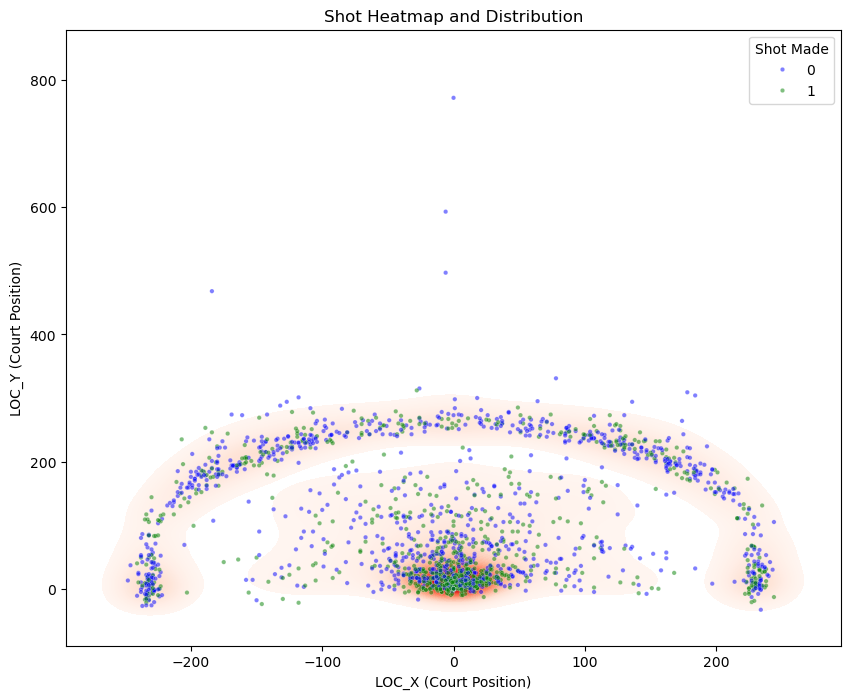

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))


sns.kdeplot(
    x=df_encoded["LOC_X"], 
    y=df_encoded["LOC_Y"], 
    shade=True, 
    cmap="Reds", 
    fill=True, 
    thresh=0.05, 
    levels=100
)


sns.scatterplot(
    x="LOC_X", 
    y="LOC_Y", 
    hue="SHOT_MADE_FLAG", 
    data=df_encoded.sample(2000), 
    palette={0:"blue", 1:"green"},
    alpha=0.5,
    s=10
)

plt.title("Shot Heatmap and Distribution")
plt.xlabel("LOC_X (Court Position)")
plt.ylabel("LOC_Y (Court Position)")
plt.legend(title="Shot Made", loc="upper right")
plt.show()

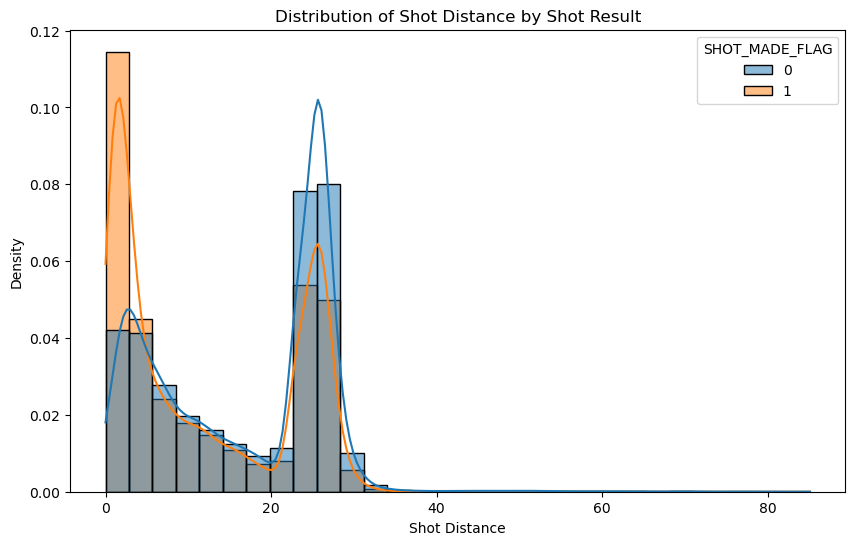

In [90]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_encoded, x="shotDistance", hue="SHOT_MADE_FLAG", bins=30, kde=True, stat="density", common_norm=False)
plt.title("Distribution of Shot Distance by Shot Result")
plt.xlabel("Shot Distance")
plt.ylabel("Density")
plt.show()

## Some studies on shooting distance and shooting accuracy

C:\Users\carls\AppData\Local\Temp\ipykernel_21324\1828745916.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_range = np.linspace(X.min()[0], X.max()[0], 300).reshape(-1, 1)
c:\Users\carls\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


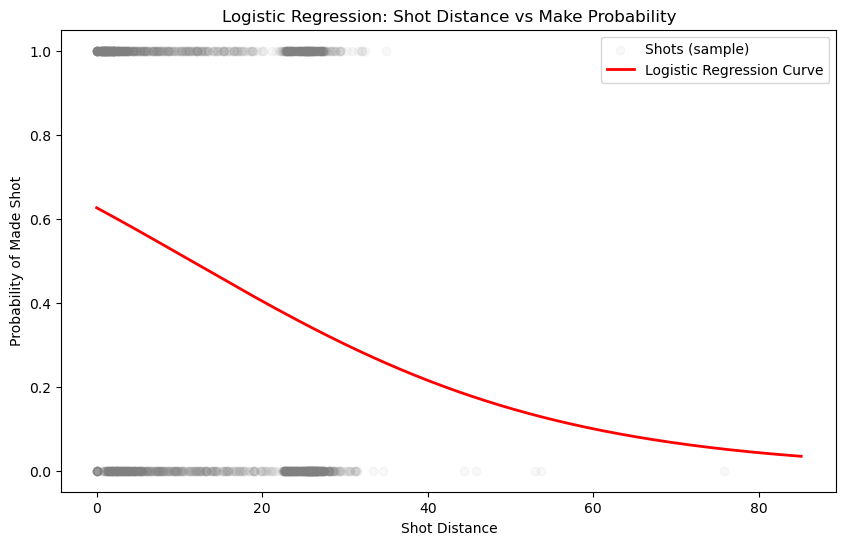

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

X = df_encoded[["shotDistance"]]
y = df_encoded["SHOT_MADE_FLAG"]


model = LogisticRegression()
model.fit(X, y)


x_range = np.linspace(X.min()[0], X.max()[0], 300).reshape(-1, 1)
y_pred = model.predict_proba(x_range)[:, 1]

plt.figure(figsize=(10,6))


plt.scatter(X.sample(2000, random_state=42), 
            y.sample(2000, random_state=42), 
            alpha=0.05, color="gray", label="Shots (sample)")

plt.plot(x_range, y_pred, color="red", linewidth=2, label="Logistic Regression Curve")

plt.xlabel("Shot Distance")
plt.ylabel("Probability of Made Shot")
plt.title("Logistic Regression: Shot Distance vs Make Probability")
plt.legend()
plt.show()

C:\Users\carls\AppData\Local\Temp\ipykernel_21324\1060242938.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_range = np.linspace(X.min()[0], X.max()[0], 300).reshape(-1, 1)
c:\Users\carls\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


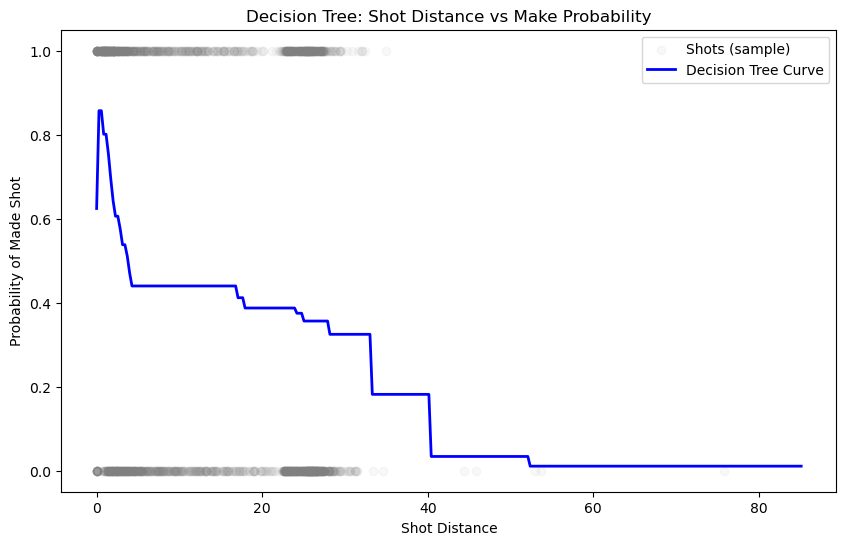

In [92]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X, y)


x_range = np.linspace(X.min()[0], X.max()[0], 300).reshape(-1, 1)
y_pred_tree = tree.predict_proba(x_range)[:,1]

plt.figure(figsize=(10,6))
plt.scatter(X.sample(2000, random_state=42), y.sample(2000, random_state=42),
            alpha=0.05, color="gray", label="Shots (sample)")
plt.plot(x_range, y_pred_tree, color="blue", linewidth=2, label="Decision Tree Curve")
plt.xlabel("Shot Distance")
plt.ylabel("Probability of Made Shot")
plt.title("Decision Tree: Shot Distance vs Make Probability")
plt.legend()
plt.show()

c:\Users\carls\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


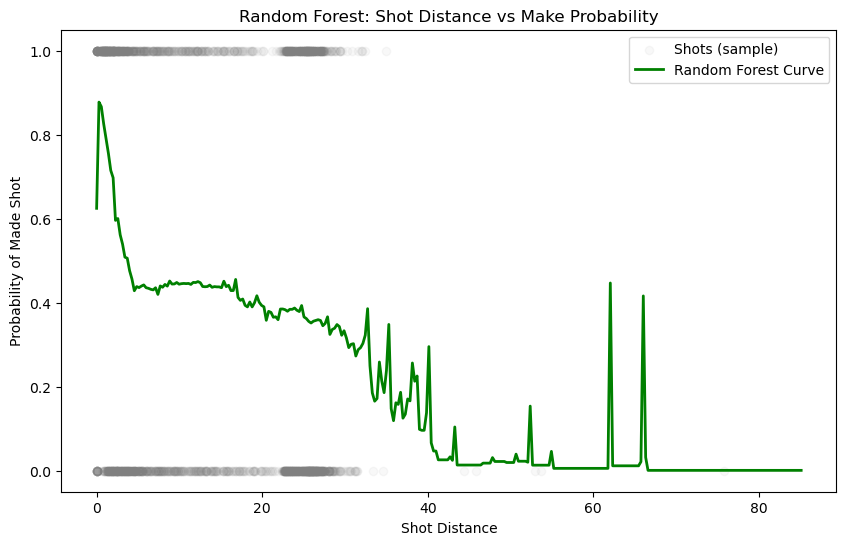

In [93]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X, y)


y_pred_rf = rf.predict_proba(x_range)[:,1]


plt.figure(figsize=(10,6))
plt.scatter(X.sample(2000, random_state=42), y.sample(2000, random_state=42),
            alpha=0.05, color="gray", label="Shots (sample)")
plt.plot(x_range, y_pred_rf, color="green", linewidth=2, label="Random Forest Curve")
plt.xlabel("Shot Distance")
plt.ylabel("Probability of Made Shot")
plt.title("Random Forest: Shot Distance vs Make Probability")
plt.legend()
plt.show()

C:\Users\carls\AppData\Local\Temp\ipykernel_21324\2902760381.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_range = np.linspace(X.min()[0], X.max()[0], 300).reshape(-1, 1)


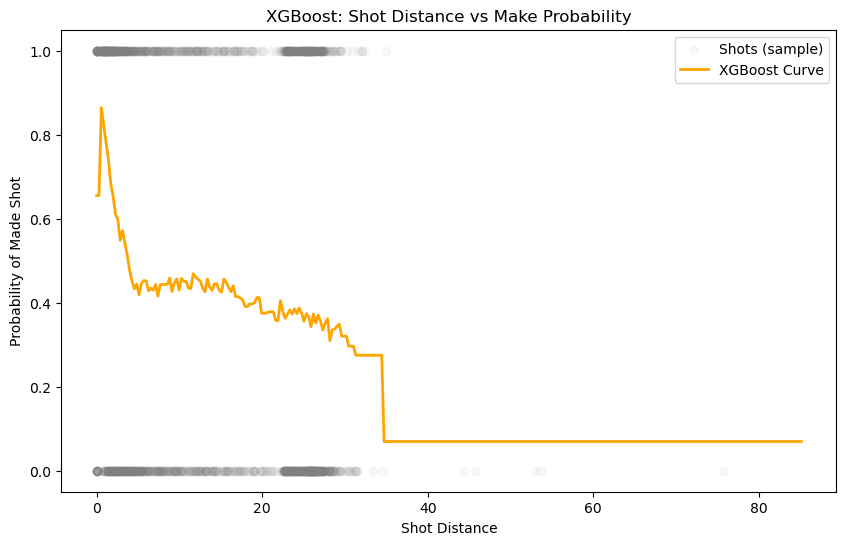

In [94]:
import xgboost as xgb
dtrain = xgb.DMatrix(X, label=y,feature_names=["shotDistance"])


params = {
    "objective": "binary:logistic",  
    "eval_metric": "logloss",
    "max_depth": 6,
    "eta": 0.1,
    "seed": 42
}


xgb_model = xgb.train(params, dtrain, num_boost_round=200)


x_range = np.linspace(X.min()[0], X.max()[0], 300).reshape(-1, 1)
dtest = xgb.DMatrix(x_range,feature_names=["shotDistance"])
y_pred_xgb = xgb_model.predict(dtest)


plt.figure(figsize=(10,6))
plt.scatter(X.sample(2000, random_state=42), y.sample(2000, random_state=42),
            alpha=0.05, color="gray", label="Shots (sample)")
plt.plot(x_range, y_pred_xgb, color="orange", linewidth=2, label="XGBoost Curve")
plt.xlabel("Shot Distance")
plt.ylabel("Probability of Made Shot")
plt.title("XGBoost: Shot Distance vs Make Probability")
plt.legend()
plt.show()

                 Model  Accuracy       AUC        F1   LogLoss
0  Logistic Regression  0.598952  0.638806  0.569613  0.664527
1        Decision Tree  0.621296  0.639098  0.482879  0.653653
2        Random Forest  0.621592  0.639897  0.485762  0.653506
3              XGBoost  0.621820  0.638785  0.486580  0.652768


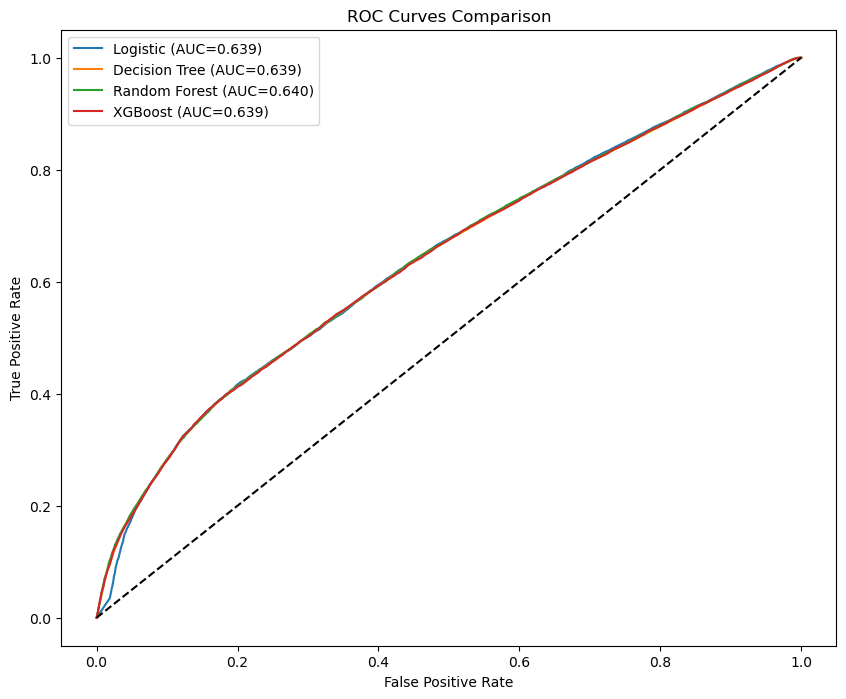

In [95]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, log_loss, roc_curve
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
y_pred_log_proba = log_reg.predict_proba(X_test)[:,1]

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
y_pred_tree_proba = tree.predict_proba(X_test)[:,1]

rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf_proba = rf.predict_proba(X_test)[:,1]

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)
params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 6,
    "eta": 0.1,
    "seed": 42
}
xgb_model = xgb.train(params, dtrain, num_boost_round=200)
y_pred_xgb_proba = xgb_model.predict(dtest)
y_pred_xgb = (y_pred_xgb_proba > 0.5).astype(int)


results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "AUC": [
        roc_auc_score(y_test, y_pred_log_proba),
        roc_auc_score(y_test, y_pred_tree_proba),
        roc_auc_score(y_test, y_pred_rf_proba),
        roc_auc_score(y_test, y_pred_xgb_proba)
    ],
    "F1": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "LogLoss": [
        log_loss(y_test, y_pred_log_proba),
        log_loss(y_test, y_pred_tree_proba),
        log_loss(y_test, y_pred_rf_proba),
        log_loss(y_test, y_pred_xgb_proba)
    ]
})

print(results)


plt.figure(figsize=(10,8))

# Logistic
fpr, tpr, _ = roc_curve(y_test, y_pred_log_proba)
plt.plot(fpr, tpr, label=f"Logistic (AUC={roc_auc_score(y_test, y_pred_log_proba):.3f})")

# Tree
fpr, tpr, _ = roc_curve(y_test, y_pred_tree_proba)
plt.plot(fpr, tpr, label=f"Decision Tree (AUC={roc_auc_score(y_test, y_pred_tree_proba):.3f})")

# RF
fpr, tpr, _ = roc_curve(y_test, y_pred_rf_proba)
plt.plot(fpr, tpr, label=f"Random Forest (AUC={roc_auc_score(y_test, y_pred_rf_proba):.3f})")

# XGB
fpr, tpr, _ = roc_curve(y_test, y_pred_xgb_proba)
plt.plot(fpr, tpr, label=f"XGBoost (AUC={roc_auc_score(y_test, y_pred_xgb_proba):.3f})")

plt.plot([0,1], [0,1], "k--")  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()

## Code for Player Shooting Types

In [97]:
df_categorical = df_categorical.to_pandas()


AttributeError: 'DataFrame' object has no attribute 'to_pandas'

In [98]:
df_categorical.head()

,ACTION_TYPE,isHomeTeam,PLAYER_ID,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,subType,SHOT_MADE_FLAG,time_remaining,time_remaining_sec,time_bin
0,Jump Shot,0,1642258,Above the Break 3,Left Side Center(LC),24+ ft.,Jump Shot,0,703,703.0,690
1,Driving Floating Bank Jump Shot,0,1630552,Mid-Range,Left Side(L),8-16 ft.,Jump Shot,0,698,698.0,690
2,Jump Shot,0,1630552,Above the Break 3,Right Side Center(RC),24+ ft.,Jump Shot,1,650,650.0,630
3,Jump Shot,0,1630811,Above the Break 3,Left Side Center(LC),24+ ft.,Jump Shot,0,587,587.0,570
4,Putback Layup Shot,0,203991,Restricted Area,Center(C),Less Than 8 ft.,Layup,1,584,584.0,570


In [ ]:
df_categorical["time_remaining_sec"] = df_categorical["time_remaining"].dt.total_seconds()

In [ ]:
clutch_df = df_categorical[df_categorical["time_remaining_sec"] <= 120]
clutch_df

,ACTION_TYPE,isHomeTeam,PLAYER_ID,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,subType,SHOT_MADE_FLAG,time_remaining,time_remaining_sec
23,Floating Jump shot,0,1630700,Mid-Range,Right Side(R),8-16 ft.,Jump Shot,1,0 days 00:01:11,71.0
24,Cutting Dunk Shot,0,1630552,Restricted Area,Center(C),Less Than 8 ft.,DUNK,1,0 days 00:00:51,51.0
25,Pullup Jump shot,0,1630700,Backcourt,Back Court(BC),Back Court Shot,Jump Shot,0,0 days 00:00:00,0.0
46,Turnaround Hook Shot,0,203991,Mid-Range,Right Side(R),8-16 ft.,Hook,1,0 days 00:01:42,102.0
47,Jump Shot,0,1629726,Above the Break 3,Right Side Center(RC),24+ ft.,Jump Shot,0,0 days 00:01:18,78.0
...,...,...,...,...,...,...,...,...,...,...
219496,Driving Floating Jump Shot,1,1641731,In The Paint (Non-RA),Left Side(L),8-16 ft.,Jump Shot,1,0 days 00:01:14,74.0
219497,Driving Floating Jump Shot,1,1631098,In The Paint (Non-RA),Center(C),Less Than 8 ft.,Jump Shot,0,0 days 00:00:58,58.0
219498,Hook Bank Shot,1,1641731,Restricted Area,Center(C),Less Than 8 ft.,Hook,0,0 days 00:00:19,19.0
219522,Running Dunk Shot,1,1630551,Restricted Area,Center(C),Less Than 8 ft.,DUNK,1,0 days 00:01:45,105.0


In [ ]:
clutch_df["SHOT_ZONE_BASIC"].unique()

array(['Mid-Range', 'Restricted Area', 'Backcourt', 'Above the Break 3',
       'Left Corner 3', 'In The Paint (Non-RA)', 'Right Corner 3'],
      dtype=object)

In [ ]:
df_combined_pd = df_combined.to_pandas()  

clutch_df["shotDistance"] = df_combined_pd .loc[clutch_df.index, "shotDistance"]
clutch_df["SHOT_TYPE"]   = df_combined_pd .loc[clutch_df.index, "SHOT_TYPE"]
clutch_df

C:\Users\carls\AppData\Local\Temp\ipykernel_21324\1349197170.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clutch_df["shotDistance"] = df_combined_pd .loc[clutch_df.index, "shotDistance"]
C:\Users\carls\AppData\Local\Temp\ipykernel_21324\1349197170.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clutch_df["SHOT_TYPE"]   = df_combined_pd .loc[clutch_df.index, "SHOT_TYPE"]


,ACTION_TYPE,isHomeTeam,PLAYER_ID,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,subType,SHOT_MADE_FLAG,time_remaining,time_remaining_sec,shotDistance,SHOT_TYPE
23,Floating Jump shot,0,1630700,Mid-Range,Right Side(R),8-16 ft.,Jump Shot,1,0 days 00:01:11,71.0,12.42,2PT Field Goal
24,Cutting Dunk Shot,0,1630552,Restricted Area,Center(C),Less Than 8 ft.,DUNK,1,0 days 00:00:51,51.0,0.55,2PT Field Goal
25,Pullup Jump shot,0,1630700,Backcourt,Back Court(BC),Back Court Shot,Jump Shot,0,0 days 00:00:00,0.0,58.59,3PT Field Goal
46,Turnaround Hook Shot,0,203991,Mid-Range,Right Side(R),8-16 ft.,Hook,1,0 days 00:01:42,102.0,10.27,2PT Field Goal
47,Jump Shot,0,1629726,Above the Break 3,Right Side Center(RC),24+ ft.,Jump Shot,0,0 days 00:01:18,78.0,26.26,3PT Field Goal
...,...,...,...,...,...,...,...,...,...,...,...,...
219496,Driving Floating Jump Shot,1,1641731,In The Paint (Non-RA),Left Side(L),8-16 ft.,Jump Shot,1,0 days 00:01:14,74.0,10.52,2PT Field Goal
219497,Driving Floating Jump Shot,1,1631098,In The Paint (Non-RA),Center(C),Less Than 8 ft.,Jump Shot,0,0 days 00:00:58,58.0,4.48,2PT Field Goal
219498,Hook Bank Shot,1,1641731,Restricted Area,Center(C),Less Than 8 ft.,Hook,0,0 days 00:00:19,19.0,3.27,2PT Field Goal
219522,Running Dunk Shot,1,1630551,Restricted Area,Center(C),Less Than 8 ft.,DUNK,1,0 days 00:01:45,105.0,1.56,2PT Field Goal


In [ ]:
clutch_stats_all = (
    clutch_df.groupby("subType")
    .agg(
        attempts=("SHOT_MADE_FLAG", "count"),
        makes=("SHOT_MADE_FLAG", "sum")
    )
    .reset_index()
)

clutch_stats_all["fg_pct"] = clutch_stats_all["makes"] / clutch_stats_all["attempts"]
clutch_stats_all

,subType,attempts,makes,fg_pct
0,DUNK,2293,2031,0.885739
1,Hook,806,408,0.506203
2,Jump Shot,26317,9398,0.357108
3,Layup,10270,5832,0.567868


In [ ]:
fg_stats = (
    clutch_df.groupby("SHOT_TYPE")["SHOT_MADE_FLAG"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "attempts", "sum": "makes", "mean": "fg_pct"})
)
print(fg_stats)

                attempts  makes    fg_pct
SHOT_TYPE                                
2PT Field Goal     21774  11795  0.541701
3PT Field Goal     17912   5874  0.327937


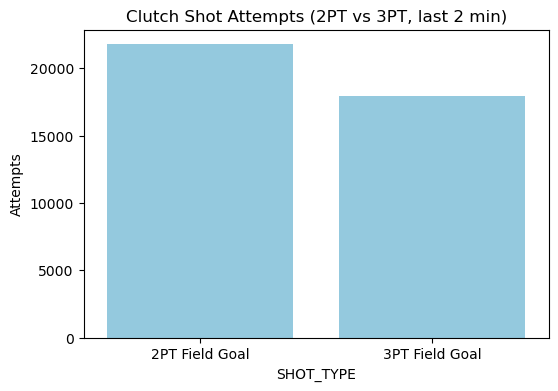

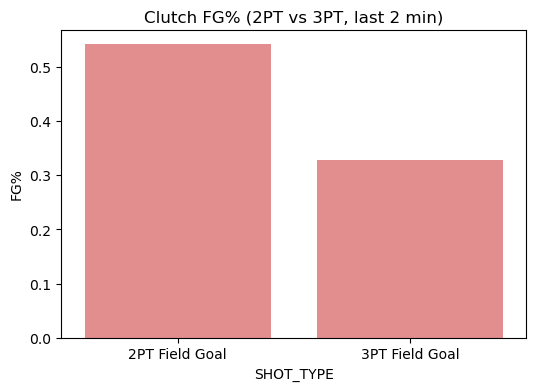

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x=fg_stats.index, y=fg_stats["attempts"], color="skyblue")
plt.title("Clutch Shot Attempts (2PT vs 3PT, last 2 min)")
plt.ylabel("Attempts")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x=fg_stats.index, y=fg_stats["fg_pct"], color="lightcoral")
plt.title("Clutch FG% (2PT vs 3PT, last 2 min)")
plt.ylabel("FG%")
plt.show()


In [ ]:
df_categorical["time_remaining"] = df_categorical["time_remaining"].dt.total_seconds().astype(int)



In [ ]:
df_combined_pd.head()

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,ACTION_TYPE,SHOT_TYPE,...,assistPlayerNameInitial,assistPersonId,assistTotal,Record_Id,game_date,isHomeTeam,time_remaining,score_margin_after,score_change,relative_margin_before
0,Shot Chart Detail,22400001,7,1642258,Zaccharie Risacher,1610612737,Atlanta Hawks,1,Jump Shot,3PT Field Goal,...,None,NaN,NaN,22400001_7,2024-11-12,0,0 days 00:11:43,0,0,0
1,Shot Chart Detail,22400001,10,1630552,Jalen Johnson,1610612737,Atlanta Hawks,1,Driving Floating Bank Jump Shot,2PT Field Goal,...,None,NaN,NaN,22400001_10,2024-11-12,0,0 days 00:11:38,0,0,0
2,Shot Chart Detail,22400001,21,1630552,Jalen Johnson,1610612737,Atlanta Hawks,1,Jump Shot,3PT Field Goal,...,K. Wallace,1630811.0,1.0,22400001_21,2024-11-12,0,0 days 00:10:50,-3,3,0
3,Shot Chart Detail,22400001,34,1630811,Keaton Wallace,1610612737,Atlanta Hawks,1,Jump Shot,3PT Field Goal,...,None,NaN,NaN,22400001_34,2024-11-12,0,0 days 00:09:47,0,0,0
4,Shot Chart Detail,22400001,36,203991,Clint Capela,1610612737,Atlanta Hawks,1,Putback Layup Shot,2PT Field Goal,...,None,NaN,NaN,22400001_36,2024-11-12,0,0 days 00:09:44,-2,2,0


## Analysis of “shotDistance”, “SHOT_TYPE”, ‘time_remaining’, and “PERIOD” on Success Rate

In [ ]:

df_behavior = df_categorical.copy()
df_behavior["shotDistance"] = df_combined_pd.loc[df_behavior.index, "shotDistance"].values
df_behavior["SHOT_TYPE"]    = df_combined_pd.loc[df_behavior.index, "SHOT_TYPE"].values
df_behavior["PERIOD"]    = df_combined_pd.loc[df_behavior.index, "PERIOD"].values


In [ ]:
df_behavior.head()



,ACTION_TYPE,isHomeTeam,PLAYER_ID,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,subType,SHOT_MADE_FLAG,time_remaining,time_remaining_sec,time_bin,shotDistance,SHOT_TYPE
0,Jump Shot,0,1642258,Above the Break 3,Left Side Center(LC),24+ ft.,Jump Shot,0,703,703.0,690,26.51,3PT Field Goal
1,Driving Floating Bank Jump Shot,0,1630552,Mid-Range,Left Side(L),8-16 ft.,Jump Shot,0,698,698.0,690,13.60,2PT Field Goal
2,Jump Shot,0,1630552,Above the Break 3,Right Side Center(RC),24+ ft.,Jump Shot,1,650,650.0,630,25.63,3PT Field Goal
3,Jump Shot,0,1630811,Above the Break 3,Left Side Center(LC),24+ ft.,Jump Shot,0,587,587.0,570,25.51,3PT Field Goal
4,Putback Layup Shot,0,203991,Restricted Area,Center(C),Less Than 8 ft.,Layup,1,584,584.0,570,2.62,2PT Field Goal


In [ ]:
X1 = df_behavior[["shotDistance", "SHOT_TYPE", "time_remaining","PERIOD"]]
y1 = df_behavior["SHOT_MADE_FLAG"]

X1 = pd.get_dummies(X1, columns=["SHOT_TYPE"])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.3, random_state=42)

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6242369947462723


In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.6234626013544292


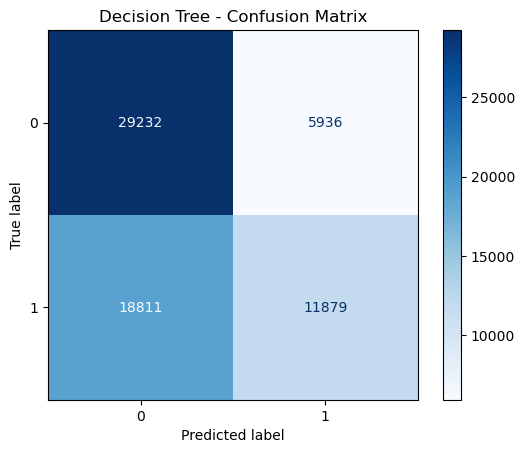

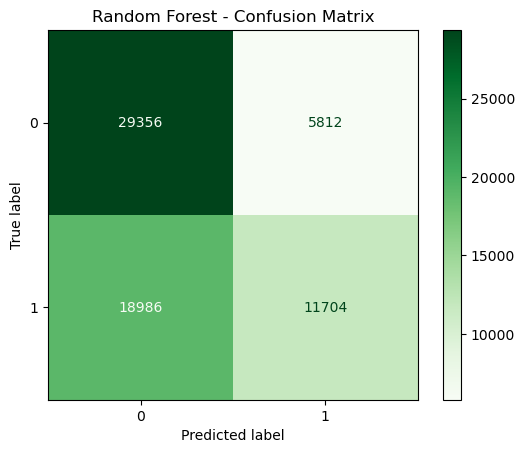

Decision Tree - Classification Report
              precision    recall  f1-score   support

           0       0.61      0.83      0.70     35168
           1       0.67      0.39      0.49     30690

    accuracy                           0.62     65858
   macro avg       0.64      0.61      0.60     65858
weighted avg       0.64      0.62      0.60     65858

Random Forest - Classification Report
              precision    recall  f1-score   support

           0       0.61      0.83      0.70     35168
           1       0.67      0.38      0.49     30690

    accuracy                           0.62     65858
   macro avg       0.64      0.61      0.59     65858
weighted avg       0.64      0.62      0.60     65858



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=dt.classes_)
disp_dt.plot(cmap="Blues")
plt.title("Decision Tree - Confusion Matrix")
plt.show()
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf.classes_)
disp_rf.plot(cmap="Greens")
plt.title("Random Forest - Confusion Matrix")
plt.show()

print("Decision Tree - Classification Report")
print(classification_report(y_test, y_pred_dt))
print("Random Forest - Classification Report")
print(classification_report(y_test, y_pred_rf))

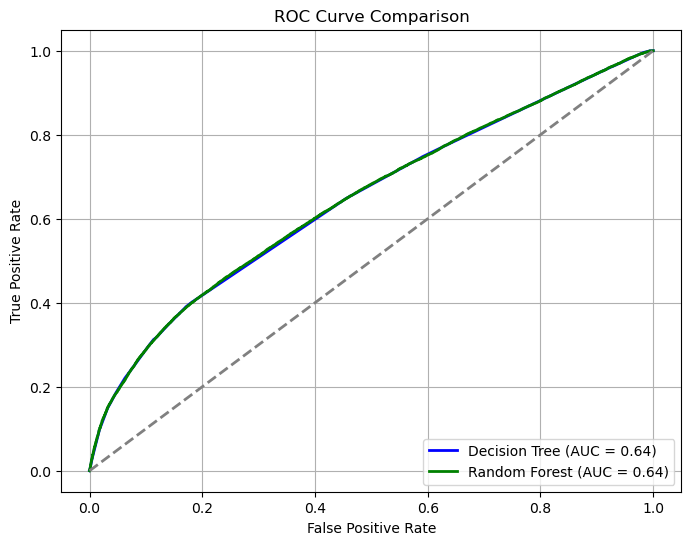

In [ ]:
y_proba_dt = dt.predict_proba(X_test)[:,1] 
y_proba_rf = rf.predict_proba(X_test)[:,1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_dt, tpr_dt, color="blue", lw=2, label=f"Decision Tree (AUC = {roc_auc_dt:.2f})")
plt.plot(fpr_rf, tpr_rf, color="green", lw=2, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot([0,1], [0,1], color="gray", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X1.columns)
importances = importances.sort_values(ascending=True)
print(importances.sort_values(ascending=False))



shotDistance                0.678942
SHOT_TYPE_2PT Field Goal    0.109297
time_remaining              0.097784
SHOT_TYPE_3PT Field Goal    0.096975
PERIOD                      0.017002
dtype: float64


## Analysis of Players' Shooting Percentage as the Game Progresses

In [ ]:
fg_by_period = (
    df_behavior.groupby("PERIOD")["SHOT_MADE_FLAG"]
    .mean()
    .reset_index()
)
print(fg_by_period)

   PERIOD  SHOT_MADE_FLAG
0       1        0.468617
1       2        0.462967
2       3        0.474217
3       4        0.463663
4       5        0.426261
5       6        0.484375


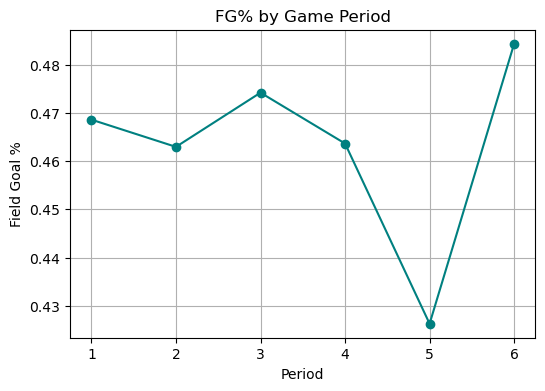

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(fg_by_period["PERIOD"], fg_by_period["SHOT_MADE_FLAG"], marker="o", color="teal")
plt.xticks([1,2,3,4,5,6])
plt.xlabel("Period")
plt.ylabel("Field Goal %")
plt.title("FG% by Game Period")
plt.grid(True)
plt.show()

## Analysis of Shooting Accuracy in Leading, Tied, and Trailing Scenarios During Matches

In [ ]:

df_margin = df_behavior.copy()
def game_state(margin):
    if margin > 0:
        return "Leading"
    elif margin < 0:
        return "Trailing"
    else:
        return "Tied"

df_margin["GameState"] = df_combined_pd["score_margin_after"].apply(game_state)

fg_by_state = (
    df_margin.groupby("GameState")["SHOT_MADE_FLAG"]
    .mean()
    .reset_index()
)
print(fg_by_state)


  GameState  SHOT_MADE_FLAG
0   Leading        0.470175
1      Tied        0.406980
2  Trailing        0.470541


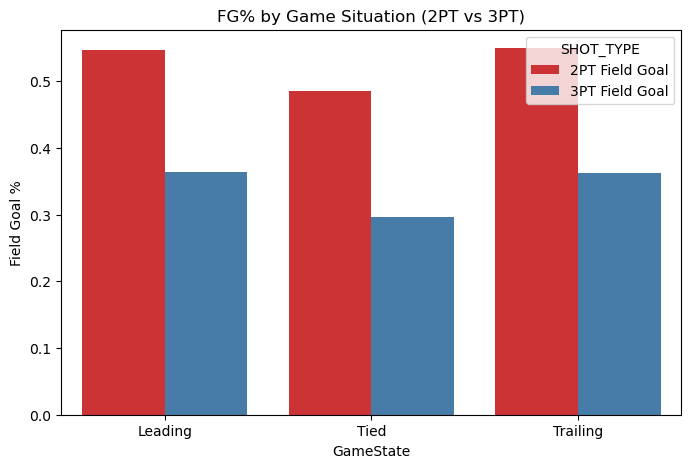

In [ ]:
fg_by_state_type = (
    df_margin.groupby(["GameState","SHOT_TYPE"])["SHOT_MADE_FLAG"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=fg_by_state_type, x="GameState", y="SHOT_MADE_FLAG", hue="SHOT_TYPE", palette="Set1")
plt.title("FG% by Game Situation (2PT vs 3PT)")
plt.ylabel("Field Goal %")
plt.show()

In [99]:
df_combined_pd.to_csv("nba_shot_data_cleaned.csv", index=False)